## Validating human input


Validating human input in an automated workflow, especially using interrupts in a Human-in-the-Loop (HITL) system, is a crucial technique to maintain data quality and ensure the process can continue correctly.

The core idea is to implement a retry loop that keeps the workflow paused until the human provides data that meets all required constraints.

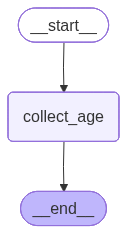

In [3]:

from typing import TypedDict


from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt


class FormState(TypedDict):
    age: int | None


def get_age_node(state: FormState):
    prompt = "What is your age?"

    while True:
        answer = interrupt(prompt)  # payload surfaces in result["__interrupt__"]

        if isinstance(answer, int) and answer > 0:
            return {"age": answer}

        prompt = f"'{answer}' is not a valid age. Please enter a positive number."


builder = StateGraph(FormState)
builder.add_node("collect_age", get_age_node)
builder.add_edge(START, "collect_age")
builder.add_edge("collect_age", END)


from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
graph = builder.compile(checkpointer=checkpointer)


builder.compile(checkpointer=checkpointer)


In [4]:
config = {"configurable": {"thread_id": "form-1"}}
first = graph.invoke({"age": None}, config=config)
print(first["__interrupt__"])  # -> [Interrupt(value='What is your age?', ...)]



[Interrupt(value='What is your age?', id='80cd071b59da10b5d05e014159804dfd')]


In [5]:
# Provide invalid data; the node re-prompts
retry = graph.invoke(Command(resume="thirty"), config=config)
print(retry["__interrupt__"])  # -> [Interrupt(value="'thirty' is not a valid age...", ...)]



[Interrupt(value="'thirty' is not a valid age. Please enter a positive number.", id='80cd071b59da10b5d05e014159804dfd')]


In [6]:
# Provide valid data; loop exits and state updates
final = graph.invoke(Command(resume=30), config=config)
print(final["age"])  # -> 30

30


## Example 2

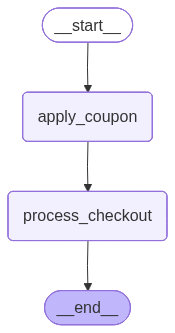

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import Command, interrupt

# --- 1. Define the State for the New Domain (E-commerce) ---
class OrderState(TypedDict):
    """The state holds order details and the coupon code."""
    order_id: str
    subtotal: float
    coupon_code: str | None
    
# --- 2. Define Workflow Nodes ---

def apply_coupon_node(state: OrderState):
    """Node 1: Collect and validate the coupon code from the user."""
    
    # Initial prompt, which can be re-issued if validation fails
    prompt = "Please enter your coupon code (e.g., SAVE2025):"

    while True:
        # interrupt() pauses execution and returns the human's input (coupon code) upon resume
        coupon_input = interrupt(prompt)

        # Validation Logic: Ensure the input is a non-empty string
        if isinstance(coupon_input, str) and coupon_input.strip() != "":
            # Basic validation passed: return the cleaned code and exit the loop
            return {"coupon_code": coupon_input.strip()}

        # Validation failed: set a new, informative prompt for the next interrupt cycle
        prompt = f"'{coupon_input}' is not a valid code format. Please enter a non-empty string code."
        
def process_checkout_node(state: OrderState):
    """Node 2: Final step after successful validation."""
    print("--- CHECKOUT INITIATED ---")
    print(f"Order {state['order_id']} ready for payment.")
    print(f"Coupon Code '{state['coupon_code']}' will now be applied to the subtotal of ${state['subtotal']:.2f}.")
    return state # Workflow completes

# --- 3. Build and Compile Graph ---
builder = StateGraph(OrderState)
builder.add_node("apply_coupon", apply_coupon_node)
builder.add_node("process_checkout", process_checkout_node)

builder.add_edge(START, "apply_coupon")
builder.add_edge("apply_coupon", "process_checkout")
builder.add_edge("process_checkout", END)

# Compile the graph
checkpointer = MemorySaver()
order_graph = builder.compile(checkpointer=checkpointer)
builder.compile(checkpointer=checkpointer)

In [4]:
# --- Setup: Define a consistent thread ID ---
config = {"configurable": {"thread_id": "order-456"}}

# --- 1. Initial Invoke (Will pause at 'apply_coupon' node) ---
# Start the workflow with initial order data
first = order_graph.invoke({"order_id": "ORD-456", "subtotal": 100.00, "coupon_code": None}, config=config)
print("--- Initial Pause ---")
# Expected Output: The initial prompt asking for the cSoupon code
print(first.get("__interrupt__"))
# Expected Output: [Interrupt(value='Please enter your coupon code (e.g., SAVE2025):', ...)]
print("-" * 30)


--- Initial Pause ---
[Interrupt(value='Please enter your coupon code (e.g., SAVE2025):', id='e29da6eb772e686926bb16ae04618304')]
------------------------------


In [5]:

# --- 2. Provide invalid data (Empty string); the node re-prompts ---
# Resume with an invalid coupon (an empty string that fails validation)
retry = order_graph.invoke(Command(resume="  "), config=config)
print("--- Invalid Resume (Re-prompt) ---")
# Expected Output: The error message and new prompt
print(retry.get("__interrupt__"))
# Expected Output: [Interrupt(value="'  ' is not a valid code format. Please enter a non-empty string code.", ...)]
print("-" * 30)



--- Invalid Resume (Re-prompt) ---
[Interrupt(value="'  ' is not a valid code format. Please enter a non-empty string code.", id='e29da6eb772e686926bb16ae04618304')]
------------------------------


In [6]:
# --- 3. Provide valid data; loop exits and state updates ---
# Resume with a valid coupon code (a non-empty string)
final = order_graph.invoke(Command(resume="FLASH25"), config=config)
print("--- Valid Resume (Final State) ---")
# Expected Output: The final state with the coupon_code updated
print("Final State Coupon:", final["coupon_code"])
# Expected Output: Final State Coupon: FLASH25

--- CHECKOUT INITIATED ---
Order ORD-456 ready for payment.
Coupon Code 'FLASH25' will now be applied to the subtotal of $100.00.
--- Valid Resume (Final State) ---
Final State Coupon: FLASH25
